# 03 – Preprocessing: Manejo de Outliers

**Proyecto:** Predicción de Subempleo por Insuficiencia de Horas — EPEN 2024  
**Dataset de entrada:** `epen_missing_handled.csv` (universo analítico: trabajadores ocupados ≥ 14 años)

---

## Objetivo

Este notebook identifica y trata valores atípicos en las variables numéricas relevantes del dataset, con foco especial en:

- **Variables de edad** (`C208`)
- **Variables de horas trabajadas** (`C318_T`, `C328_T`, `whoraT`, `C331`)
- **Variables de ingresos** (`INGTOT`, `INGTOTP`, `INGTRABW`, `I339_1`, `I342`, `I345_1`, `I348`)

> **Importante:** No todos los valores extremos deben eliminarse automáticamente. En el contexto de encuestas laborales, valores extremos pueden representar casos reales y válidos (por ejemplo, trabajadores con ingresos muy altos o jornadas extendidas). La estrategia de tratamiento se justifica caso a caso.

**Restricciones de este notebook:**
-  No se realiza encoding categórico
-  No se hace train/test split
-  No se aplica balanceo de clases
-  No se entrena ningún modelo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Cargar dataset

In [2]:
# Rutas candidatas de entrada
data_dir = Path("../data/processed")
path_missing = data_dir / "epen_missing_handled.csv"
path_target  = data_dir / "epen_target_defined.csv"

if path_missing.exists():
    df = pd.read_csv(path_missing, low_memory=False)
    print(f"Dataset cargado desde: {path_missing}")
elif path_target.exists():
    df = pd.read_csv(path_target, low_memory=False)
    print(f"  'epen_missing_handled.csv' no encontrado.")
    print(f"    Dataset cargado desde fallback: {path_target}")
    print("    Se recomienda ejecutar primero: 01_missing_values_handling.ipynb")
else:
    raise FileNotFoundError(
        "\n No se encontró ningún dataset de entrada.\n"
        "   Por favor ejecutá primero los siguientes notebooks en orden:\n"
        "   1. 02_data_understanding/03_target_definition.ipynb\n"
        "   2. 03_preprocessing/01_missing_values_handling.ipynb\n"
    )

print(f"\nDimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print("\n--- Primeras filas ---")
display(df.head())
print(f"\n--- Columnas disponibles ({df.shape[1]}) ---")
print(list(df.columns))

Dataset cargado desde: ..\data\processed\epen_missing_handled.csv

Dimensiones del dataset: 24,054 filas × 138 columnas

--- Primeras filas ---


,ANIO,MES,CONGLOMERADO,MUESTRA,SELVIV,HOGAR,REGION,LLAVE_PANEL,ESTRATO,C201,C203,C204,C205,C206,C207,C208,C300n,NROINF,C301_DIA,C301_MES,C301_ANIO,C303,C304,C305,C306_1,C306_2,C306_3,C306_4,C306_5,C306_6,...,C375_3,C375_4,C375_5,C375_6,C376,C377,OCUP300,I339_1,D341_T,I342,D344,I345_1,I348,D347_T,D350,D351_T,INGTOT,INGTOTP,ingtrabw,RESIDENT,fa_ond24,fa_efm24,fa_amj24,fa_jas24,C208_num,OCUP300_num,P209H_num,target_subempleo_horas,whoraT_missing_flag,C318_T_missing_flag
0,2024,10,18117,2,61,1,1,"202,410,181,172,006,016.00",1,1,1,1,2,,2,60,1,1,19.00,5.00,1964,1,,,,,,,,,...,2,2,2,2,10,7,1,,,1367,,,,,,,1367,1367,1367,1,700.40,NaN,NaN,NaN,60.00,1.00,2.00,0,0,0
1,2024,10,18117,2,61,1,1,"202,410,181,172,006,016.00",1,2,7,1,2,,2,49,2,2,30.00,11.00,1974,1,,,,,,,,,...,2,2,2,2,10,7,1,,,1404,130,,,,,,1534,1534,1534,1,700.40,NaN,NaN,NaN,49.00,1.00,1.00,1,0,0
2,2024,10,1823302,1,59,1,1,"20,241,018,233,021,001,728.00",1,1,1,1,2,,1,52,1,2,14.00,9.00,1972,1,,,,,,,,,...,2,2,2,2,10,7,1,,,1400,,,,,,,1400,1400,1400,1,896.47,NaN,NaN,NaN,52.00,1.00,2.00,0,0,0
3,2024,10,1823302,1,59,1,1,"20,241,018,233,021,001,728.00",1,2,2,1,2,,2,51,2,2,10.00,10.00,1972,1,,,,,,,,,...,2,2,2,2,1,1,1,1516,,,,,,,,,1516,1516,1516,1,844.04,NaN,NaN,NaN,51.00,1.00,2.00,0,0,0
4,2024,10,1823302,1,60,1,1,"20,241,018,233,021,001,728.00",1,1,1,1,2,,2,43,1,1,25.00,4.00,1981,1,,,,,,,,,...,2,2,2,2,10,1,1,1083,,,,,,,,,1083,1083,1083,1,"1,017.65",NaN,NaN,NaN,43.00,1.00,2.00,0,0,0



--- Columnas disponibles (138) ---
['ANIO', 'MES', 'CONGLOMERADO', 'MUESTRA', 'SELVIV', 'HOGAR', 'REGION', 'LLAVE_PANEL', 'ESTRATO', 'C201', 'C203', 'C204', 'C205', 'C206', 'C207', 'C208', 'C300n', 'NROINF', 'C301_DIA', 'C301_MES', 'C301_ANIO', 'C303', 'C304', 'C305', 'C306_1', 'C306_2', 'C306_3', 'C306_4', 'C306_5', 'C306_6', 'C306_7', 'C306_8', 'C306_9', 'C306_10', 'C306_10A', 'C306_11', 'C306A', 'C308_COD', 'C309_COD', 'C310', 'C311', 'C312', 'C313', 'C317', 'C317A', 'C318_1', 'C318_2', 'C318_3', 'C318_4', 'C318_5', 'C318_6', 'C318_7', 'C318_T', 'C328_T', 'whoraT', 'C330', 'C331', 'C333', 'C334', 'P209H', 'C335', 'C338', 'C339_1', 'C341_T', 'C342', 'C344', 'C345_1', 'C347_T', 'C348', 'C350', 'C352', 'C353', 'C354', 'C355', 'C356', 'C357_I', 'C358', 'C359', 'SEGURO1', 'C361_1', 'C362_1', 'C361_2', 'C362_2', 'C361_3', 'C362_3', 'C361_4', 'C362_4', 'C361_5', 'C362_5', 'C361_6', 'C362_6', 'C361_7', 'C362_7', 'C361_8', 'C362_8', 'C364_1', 'C365_1', 'C364_2', 'C365_2', 'C364_3', 'C365_3'

In [3]:
# Distribución del target
if "target_subempleo_horas" in df.columns:
    print("--- Distribución de target_subempleo_horas ---")
    target_dist = df["target_subempleo_horas"].value_counts(dropna=False)
    target_pct  = df["target_subempleo_horas"].value_counts(normalize=True, dropna=False).mul(100).round(2)
    target_df   = pd.DataFrame({"cantidad": target_dist, "porcentaje (%)": target_pct})
    target_df.index.name = "target_subempleo_horas"
    display(target_df)
else:
    print("  Columna 'target_subempleo_horas' no encontrada en el dataset.")

--- Distribución de target_subempleo_horas ---


,cantidad,porcentaje (%)
target_subempleo_horas,,
0,18064,75.10
1,5990,24.90


## 3. Validación inicial

Antes de analizar outliers, se verifican tres condiciones mínimas:

1. Que la variable `target_subempleo_horas` exista en el dataset.
2. Que el target no tenga valores nulos (no debe haber sido modificado).
3. Que las variables de **leakage** (`P209H`, `C333`, `C334`) sean identificadas y excluidas del análisis predictivo.

In [4]:
# --- Validación 1: existencia del target ---
assert "target_subempleo_horas" in df.columns, \
    " 'target_subempleo_horas' no existe. Ejecutar primero 03_target_definition.ipynb"
print("✔ 'target_subempleo_horas' encontrado en el dataset.")

# --- Validación 2: target sin nulos ---
nulos_target = df["target_subempleo_horas"].isna().sum()
assert nulos_target == 0, f" target_subempleo_horas tiene {nulos_target} nulos."
print(f"✔ target_subempleo_horas no tiene valores nulos ({len(df):,} registros).")

# --- Validación 3: variables de leakage ---
LEAKAGE_VARS = ["P209H", "C333", "C334"]
leakage_present = [v for v in LEAKAGE_VARS if v in df.columns]
if leakage_present:
    print(f"\n  Variables de leakage presentes en el dataset: {leakage_present}")
    print("   Estas variables NO serán utilizadas en el análisis de outliers ni en modelos predictivos.")
else:
    print(f"\n✔ Ninguna variable de leakage {LEAKAGE_VARS} encontrada en el dataset.")

print("\nValidación inicial completada.")

✔ 'target_subempleo_horas' encontrado en el dataset.
✔ target_subempleo_horas no tiene valores nulos (24,054 registros).

  Variables de leakage presentes en el dataset: ['P209H', 'C333', 'C334']
   Estas variables NO serán utilizadas en el análisis de outliers ni en modelos predictivos.

Validación inicial completada.


## 4. Selección de variables numéricas candidatas

Se definen las variables numéricas de interés para el análisis de outliers, agrupadas por dominio:

| Grupo | Variables |
|---|---|
| **Edad** | `C208` |
| **Horas trabajadas** | `C318_T`, `C328_T`, `whoraT`, `C331` |
| **Ingresos** | `INGTOT`, `INGTOTP`, `INGTRABW`, `I339_1`, `I342`, `I345_1`, `I348` |

Solo se analizarán las columnas que efectivamente existan en el DataFrame cargado.

In [5]:
# Candidatas completas
numeric_outlier_candidates = [
    "C208",      # edad
    "C318_T",    # horas trabajadas en ocupación principal
    "C328_T",    # horas trabajadas en ocupaciones secundarias
    "whoraT",    # horas totales trabajadas
    "C331",      # horas normalmente trabajadas
    "INGTOT",    # ingresos totales
    "INGTOTP",   # ingreso principal mensual
    "INGTRABW",  # ingreso mensual laboral (mayúsculas)
    "ingtrabw",  # ingreso mensual laboral (minúsculas — nombre real en el CSV)
    "I339_1",    # ingreso mensual dependiente principal
    "I342",      # ingreso mensual independiente principal
    "I345_1",    # ingreso mensual dependiente secundario
    "I348",      # ingreso mensual independiente secundario
]

# Filtrar: columna debe existir Y tener dtype numérico
# (algunas columnas se graban como object en el CSV aunque debieran ser numéricas)
numeric_cols   = []
non_numeric    = []
missing_cols   = []

for c in numeric_outlier_candidates:
    if c not in df.columns:
        missing_cols.append(c)
    elif pd.api.types.is_numeric_dtype(df[c]):
        numeric_cols.append(c)
    else:
        non_numeric.append(c)

# Intentar coercionar columnas object que podrían ser numéricas
for c in non_numeric:
    converted = pd.to_numeric(df[c], errors="coerce")
    if converted.notna().sum() > 0:
        df[c] = converted
        numeric_cols.append(c)
        print(f"  '{c}' convertida a numérico con pd.to_numeric.")
    else:
        print(f"  '{c}' no pudo convertirse a numérico — se excluye del análisis.")

print(f"\nVariables candidatas definidas   : {len(numeric_outlier_candidates)}")
print(f"Variables numéricas para análisis: {len(numeric_cols)}")
print(f"  → {numeric_cols}")
if missing_cols:
    print(f"\nNO encontradas en el dataset ({len(missing_cols)}): {missing_cols}")

# Normalizar: si existe 'ingtrabw' (minúsculas) pero no 'INGTRABW', usar el nombre real
INGTRABW_col = "INGTRABW" if "INGTRABW" in numeric_cols else ("ingtrabw" if "ingtrabw" in numeric_cols else None)

# Sub-listas por dominio (solo presentes y numéricas)
age_cols    = [c for c in ["C208"] if c in numeric_cols]
hours_cols  = [c for c in ["C318_T", "C328_T", "whoraT", "C331"] if c in numeric_cols]
income_cols = [c for c in ["INGTOT", "INGTOTP", "INGTRABW", "ingtrabw",
                            "I339_1", "I342", "I345_1", "I348"] if c in numeric_cols]

# Eliminar duplicados conservando el orden
seen = set()
income_cols = [c for c in income_cols if not (c in seen or seen.add(c))]

print(f"\nEdad    : {age_cols}")
print(f"Horas   : {hours_cols}")
print(f"Ingresos: {income_cols}")

  'C328_T' convertida a numérico con pd.to_numeric.
  'C331' convertida a numérico con pd.to_numeric.
  'INGTOT' convertida a numérico con pd.to_numeric.
  'INGTOTP' convertida a numérico con pd.to_numeric.
  'ingtrabw' convertida a numérico con pd.to_numeric.
  'I339_1' convertida a numérico con pd.to_numeric.
  'I342' convertida a numérico con pd.to_numeric.
  'I345_1' convertida a numérico con pd.to_numeric.
  'I348' convertida a numérico con pd.to_numeric.

Variables candidatas definidas   : 13
Variables numéricas para análisis: 12
  → ['C208', 'C318_T', 'whoraT', 'C328_T', 'C331', 'INGTOT', 'INGTOTP', 'ingtrabw', 'I339_1', 'I342', 'I345_1', 'I348']

NO encontradas en el dataset (1): ['INGTRABW']

Edad    : ['C208']
Horas   : ['C318_T', 'C328_T', 'whoraT', 'C331']
Ingresos: ['INGTOT', 'INGTOTP', 'ingtrabw', 'I339_1', 'I342', 'I345_1', 'I348']


## 5. Resumen estadístico inicial

Se calcula un resumen con percentiles clave para cada variable numérica de interés.  
Los percentiles p01, p05, p95 y p99 permiten identificar colas extremas sin que la media o la desviación estándar oculten la asimetría.

In [6]:
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
pct_labels  = ["p01", "p05", "p25", "p50", "p75", "p95", "p99"]

rows = []
for col in numeric_cols:
    s = pd.to_numeric(df[col], errors="coerce").dropna()   # garantiza dtype numérico
    if s.empty:
        print(f"  '{col}' vacía después de coerción — omitida.")
        continue
    pcts = s.quantile(percentiles).to_numpy()              # array numpy, sin índice flotante
    row = {
        "variable": col,
        "count"   : int(s.count()),
        "mean"    : float(s.mean()),
        "std"     : float(s.std()),
        "min"     : float(s.min()),
    }
    for label, val in zip(pct_labels, pcts):
        row[label] = float(val)
    row["max"] = float(s.max())
    rows.append(row)

outlier_numeric_summary = pd.DataFrame(rows).set_index("variable")

# Mostrar redondeado (no requiere jinja2)
display(outlier_numeric_summary.round(2))

,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
variable,,,,,,,,,,,,
C208,24054,42.02,14.79,14.00,16.00,20.00,30.00,41.00,53.00,67.00,76.00,92.00
C318_T,24054,40.78,18.84,0.00,0.00,6.00,30.00,42.00,50.00,72.00,84.00,112.00
whoraT,24054,44.50,17.90,2.00,4.00,12.00,36.00,46.00,54.00,73.00,89.00,118.00
C328_T,2450,14.36,12.15,2.00,2.00,2.00,6.00,10.00,20.00,40.00,56.00,87.00
C331,3440,42.40,16.26,2.00,5.00,12.00,32.00,45.00,48.00,70.00,84.00,112.00
INGTOT,23280,"2,047.38","2,064.66",3.00,87.00,260.00,"1,025.00","1,516.00","2,500.00","5,025.75","10,000.00","40,000.00"
INGTOTP,23280,"1,976.75","1,956.62",3.00,80.00,250.00,"1,025.00","1,500.00","2,400.00","5,000.00","10,000.00","40,000.00"
ingtrabw,23280,"2,195.83","2,324.55",3.00,87.00,260.00,"1,033.00","1,603.00","2,570.00","5,940.65","12,000.00","40,000.00"
I339_1,14851,"2,084.20","1,908.30",42.00,173.00,433.00,"1,050.00","1,500.00","2,500.00","5,000.00","10,000.00","32,000.00"


## 6. Visualización inicial de outliers

Se generan boxplots e histogramas para detectar visualmente la presencia y magnitud de valores atípicos en cada grupo de variables.

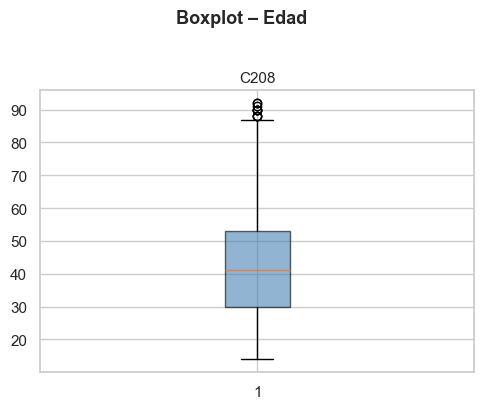

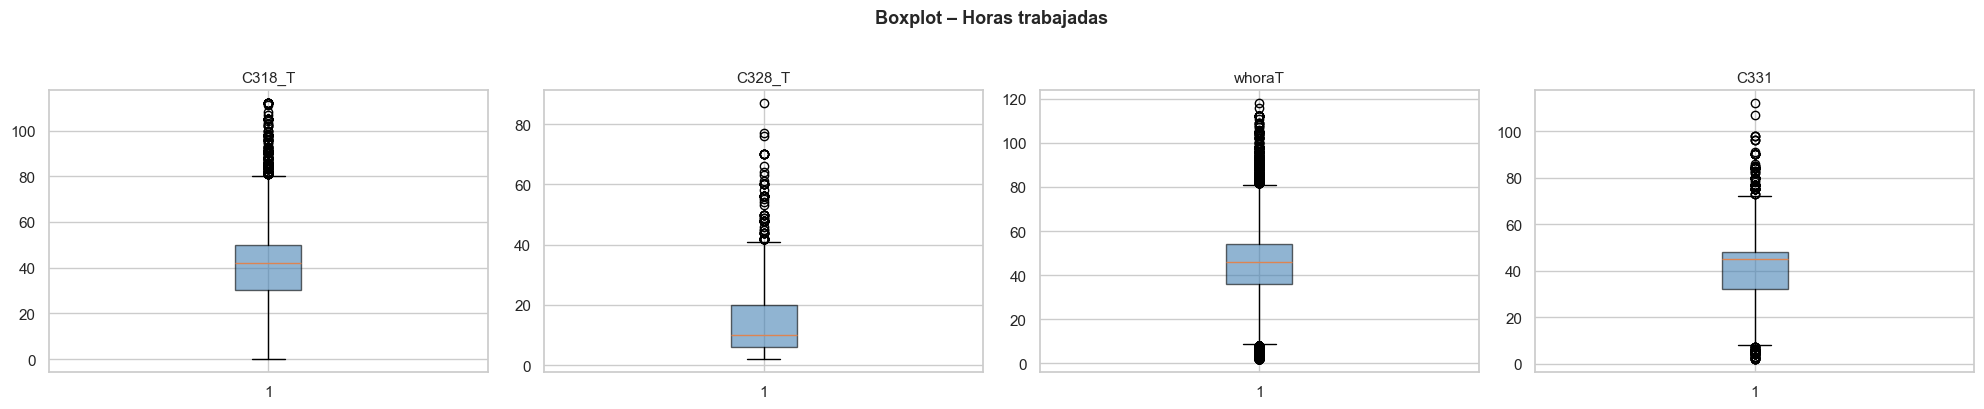

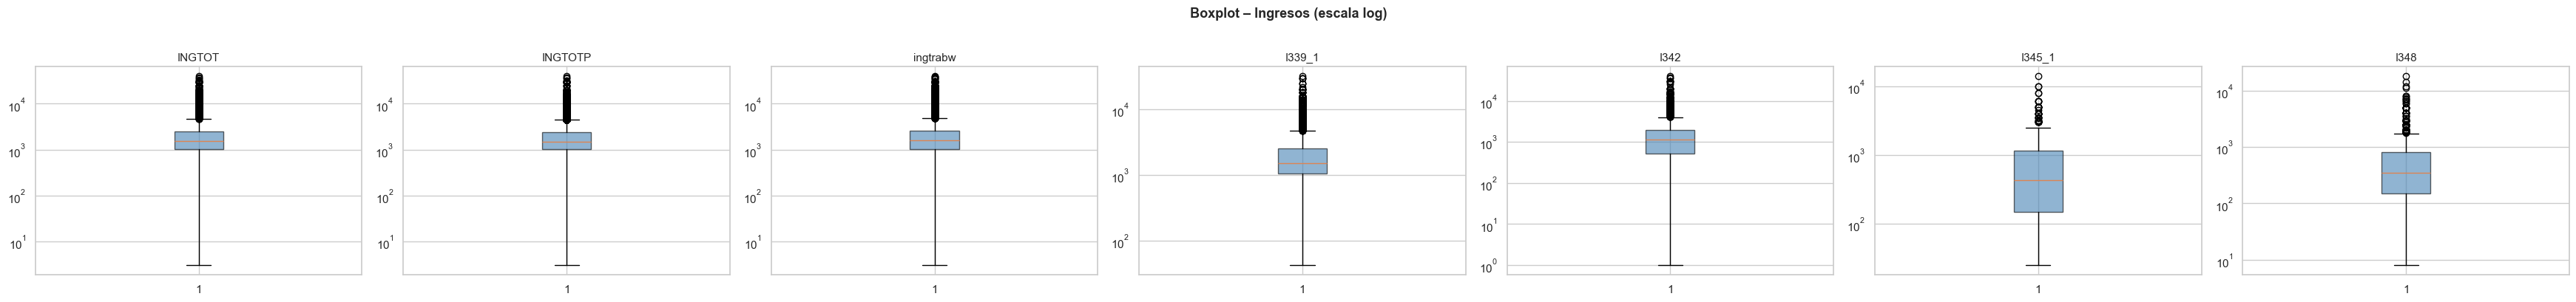

In [7]:
def boxplot_group(df, cols, title, log_scale=False):
    """Genera boxplots horizontales para un grupo de variables."""
    cols_present = [c for c in cols if c in df.columns]
    if not cols_present:
        print(f"  Sin columnas disponibles para: {title}")
        return
    n = len(cols_present)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_present):
        data = df[col].dropna()
        ax.boxplot(data, vert=True, patch_artist=True,
                   boxprops=dict(facecolor="steelblue", alpha=0.6))
        if log_scale and data.min() > 0:
            ax.set_yscale("log")
        ax.set_title(col, fontsize=11)
        ax.set_xlabel("")
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

# --- Boxplots por grupo ---
boxplot_group(df, age_cols,    "Boxplot – Edad")
boxplot_group(df, hours_cols,  "Boxplot – Horas trabajadas")
boxplot_group(df, income_cols, "Boxplot – Ingresos (escala log)", log_scale=True)

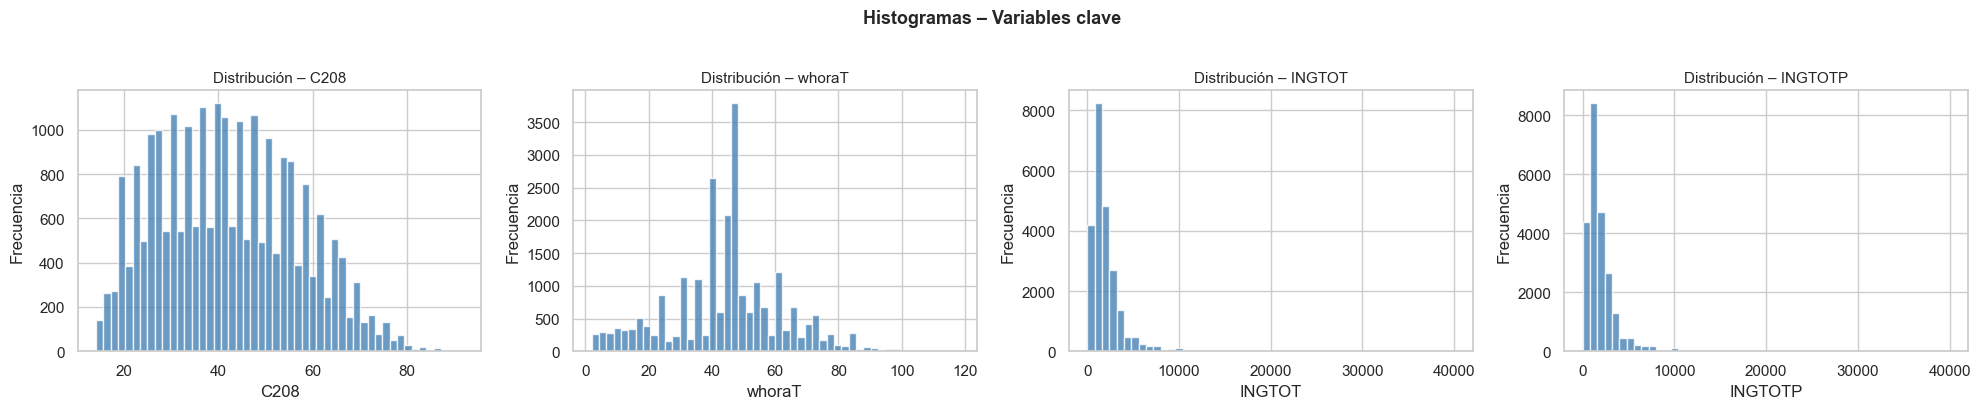

In [8]:
# --- Histogramas para variables clave ---
hist_vars = [c for c in ["C208", "whoraT", "INGTOT", "INGTOTP", "INGTRABW"] if c in df.columns]

if hist_vars:
    fig, axes = plt.subplots(1, len(hist_vars), figsize=(5 * len(hist_vars), 4))
    if len(hist_vars) == 1:
        axes = [axes]
    for ax, col in zip(axes, hist_vars):
        data = df[col].dropna()
        ax.hist(data, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
        ax.set_title(f"Distribución – {col}", fontsize=11)
        ax.set_xlabel(col)
        ax.set_ylabel("Frecuencia")
    fig.suptitle("Histogramas – Variables clave", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron las variables para histogramas.")

## 7. Identificación de outliers con método IQR

El método del rango intercuartílico (IQR) define los límites:

$$\text{lower\_bound} = Q_1 - 1.5 \times IQR \qquad \text{upper\_bound} = Q_3 + 1.5 \times IQR$$

Valores fuera de ese rango se consideran outliers estadísticos. Esto **no implica eliminarlos automáticamente**; es solo una cuantificación.

In [9]:
def detect_outliers_iqr(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """
    Calcula estadísticas de outliers por el método IQR para cada columna indicada.
    Retorna un DataFrame con Q1, Q3, IQR, límites, conteos y porcentaje de outliers.
    """
    results = []
    n_total = len(df)
    for col in columns:
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue
        q1  = float(s.quantile(0.25))
        q3  = float(s.quantile(0.75))
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n_lower   = int((s < lower).sum())
        n_upper   = int((s > upper).sum())
        n_outlier = n_lower + n_upper
        results.append({
            "variable"            : col,
            "Q1"                  : round(q1, 2),
            "Q3"                  : round(q3, 2),
            "IQR"                 : round(iqr, 2),
            "lower_bound"         : round(lower, 2),
            "upper_bound"         : round(upper, 2),
            "outliers_inferiores" : n_lower,
            "outliers_superiores" : n_upper,
            "total_outliers"      : n_outlier,
            "pct_outliers (%)"    : round(n_outlier / n_total * 100, 2),
        })
    return pd.DataFrame(results).set_index("variable")


iqr_summary = detect_outliers_iqr(df, numeric_cols)
display(iqr_summary.sort_values("pct_outliers (%)", ascending=False))

,Q1,Q3,IQR,lower_bound,upper_bound,outliers_inferiores,outliers_superiores,total_outliers,pct_outliers (%)
variable,,,,,,,,,
ingtrabw,"1,033.00","2,570.00","1,537.00","-1,272.50","4,875.50",0,1745,1745,7.25
INGTOTP,"1,025.00","2,400.00","1,375.00","-1,037.50","4,462.50",0,1595,1595,6.63
INGTOT,"1,025.00","2,500.00","1,475.00","-1,187.50","4,712.50",0,1525,1525,6.34
whoraT,36.00,54.00,18.00,9.00,81.00,840,631,1471,6.12
I339_1,"1,050.00","2,500.00","1,450.00","-1,125.00","4,675.00",0,1005,1005,4.18
I342,530.00,"1,932.00","1,402.00","-1,573.00","4,035.00",0,461,461,1.92
C318_T,30.00,50.00,20.00,0.00,80.00,0,455,455,1.89
C331,32.00,48.00,16.00,8.00,72.00,65,98,163,0.68
I348,150.00,800.00,650.00,-825.00,"1,775.00",0,130,130,0.54


## 8. Identificación de valores conceptualmente inválidos

Además del método estadístico, se aplican reglas de dominio para detectar valores que no pueden existir en el universo analítico (trabajadores ocupados ≥ 14 años):

| Regla | Variable | Criterio |
|---|---|---|
| Edad mínima | `C208` | < 14 años |
| Edad máxima revisable | `C208` | > 98 años |
| Horas negativas | horas | < 0 |
| Horas excesivas | horas | > 112 h/semana *(16 h/día × 7 días)* |
| Ingresos negativos | ingresos | < 0 |

> Los ingresos extremadamente altos **no se eliminan**: se tratarán con transformación logarítmica.

In [10]:
n_total = len(df)
conceptual_rules = []

def _add_rule(rule_name, variable, mask_series):
    """Registra una regla conceptual si la variable existe."""
    if variable not in df.columns:
        return
    n = int(mask_series.sum())
    conceptual_rules.append({
        "regla"          : rule_name,
        "variable"       : variable,
        "cantidad_casos" : n,
        "porcentaje (%)" : round(n / n_total * 100, 4),
    })

# Reglas de edad
if "C208" in df.columns:
    col_edad = pd.to_numeric(df["C208"], errors="coerce")
    _add_rule("Edad < 14", "C208", col_edad < 14)
    _add_rule("Edad > 98", "C208", col_edad > 98)

# Reglas de horas
for hcol in hours_cols:
    h = pd.to_numeric(df[hcol], errors="coerce")
    _add_rule("Horas negativas",   hcol, h < 0)
    _add_rule("Horas > 112 h/sem", hcol, h > 112)

# Reglas de ingresos
for icol in income_cols:
    ing = pd.to_numeric(df[icol], errors="coerce")
    _add_rule("Ingresos negativos", icol, ing < 0)

conceptual_outliers_summary = pd.DataFrame(conceptual_rules)
if conceptual_outliers_summary.empty:
    print("No se detectaron valores conceptualmente inválidos en las variables disponibles.")
else:
    display(
        conceptual_outliers_summary
        .sort_values("porcentaje (%)", ascending=False)
        .reset_index(drop=True)
    )

,regla,variable,cantidad_casos,porcentaje (%)
0,Horas > 112 h/sem,whoraT,2,0.01
1,Edad < 14,C208,0,0.00
2,Edad > 98,C208,0,0.00
3,Horas > 112 h/sem,C318_T,0,0.00
4,Horas negativas,C318_T,0,0.00
5,Horas negativas,C328_T,0,0.00
6,Horas > 112 h/sem,C328_T,0,0.00
7,Horas negativas,whoraT,0,0.00
8,Horas negativas,C331,0,0.00
9,Horas > 112 h/sem,C331,0,0.00


## 9. Estrategia de tratamiento

Con base en la exploración realizada, se adoptan las siguientes decisiones:

### Principio general
**No se eliminará ninguna observación automáticamente** por ser un outlier estadístico. Cada decisión está justificada por el dominio.

### Edad (`C208`)
- Valores fuera del rango **[14, 98]** se convierten a `NaN`.  
  *Justificación*: el universo analítico son trabajadores ocupados ≥ 14 años; valores > 98 podrían ser errores de carga.

### Horas trabajadas (`C318_T`, `C328_T`, `whoraT`, `C331`)
- Valores **negativos** → `NaN` (imposibles físicamente).
- Valores **> 112 h/semana** → winsorización con `clip(upper=112)`.  
  *Justificación*: 112 h equivale a 16 h diarias × 7 días; valores superiores son casi certamente errores de registro.

### Ingresos (`INGTOT`, `INGTOTP`, `INGTRABW`, `I339_1`, `I342`, `I345_1`, `I348`)
- Valores **negativos** → `NaN` (un ingreso laboral no puede ser negativo).
- Ingresos altos **no se eliminan**; se aplica transformación **`log1p`** para reducir asimetría y facilitar el entrenamiento de modelos posteriores.

### Flags de outliers
Se crean variables binarias (0/1) **antes** de modificar los valores, para preservar la información sobre qué registros fueron afectados.

## 10. Aplicar tratamiento de outliers

### 10.1 Crear copia de trabajo y flags (antes de modificar valores)

In [11]:
# Copia de trabajo — todas las modificaciones se hacen sobre esta copia
df_outliers = df.copy()

# Asegurar que todas las columnas numéricas candidatas estén en dtype numérico en la copia
for col in numeric_cols:
    df_outliers[col] = pd.to_numeric(df_outliers[col], errors="coerce")

# ============================================================
# FLAGS: construidos ANTES de modificar cualquier valor
# ============================================================

# Flag: edad fuera de rango [14, 98]
if "C208" in df_outliers.columns:
    df_outliers["C208_outlier_flag"] = (
        (df_outliers["C208"] < 14) | (df_outliers["C208"] > 98)
    ).astype(int)
    print(f"C208_outlier_flag     : {df_outliers['C208_outlier_flag'].sum():,} casos marcados")

# Flag: horas excesivas (> 112) o negativas en whoraT
if "whoraT" in df_outliers.columns:
    df_outliers["whoraT_outlier_flag"] = (
        (df_outliers["whoraT"] < 0) | (df_outliers["whoraT"] > 112)
    ).astype(int)
    print(f"whoraT_outlier_flag   : {df_outliers['whoraT_outlier_flag'].sum():,} casos marcados")

# Flag: ingresos negativos o extremos en INGTOT
if "INGTOT" in df_outliers.columns:
    q3_ing  = df_outliers["INGTOT"].quantile(0.75)
    iqr_ing = q3_ing - df_outliers["INGTOT"].quantile(0.25)
    ing_ext = q3_ing + 3 * iqr_ing
    df_outliers["INGTOT_outlier_flag"] = (
        (df_outliers["INGTOT"] < 0) | (df_outliers["INGTOT"] > ing_ext)
    ).astype(int)
    print(f"INGTOT_outlier_flag   : {df_outliers['INGTOT_outlier_flag'].sum():,} casos marcados")

# Flag: ingreso laboral (ingtrabw — nombre real en el CSV)
ingtrabw_col = "INGTRABW" if "INGTRABW" in df_outliers.columns else ("ingtrabw" if "ingtrabw" in df_outliers.columns else None)
if ingtrabw_col:
    q3_itw  = df_outliers[ingtrabw_col].quantile(0.75)
    iqr_itw = q3_itw - df_outliers[ingtrabw_col].quantile(0.25)
    itw_ext = q3_itw + 3 * iqr_itw
    df_outliers["INGTRABW_outlier_flag"] = (
        (df_outliers[ingtrabw_col] < 0) | (df_outliers[ingtrabw_col] > itw_ext)
    ).astype(int)
    print(f"INGTRABW_outlier_flag : {df_outliers['INGTRABW_outlier_flag'].sum():,} casos marcados (columna '{ingtrabw_col}')")

print("\nFlags creados correctamente (antes de modificar valores).")

C208_outlier_flag     : 0 casos marcados
whoraT_outlier_flag   : 2 casos marcados
INGTOT_outlier_flag   : 692 casos marcados
INGTRABW_outlier_flag : 768 casos marcados (columna 'ingtrabw')

Flags creados correctamente (antes de modificar valores).


### 10.2 Tratamiento de edad

In [12]:
# Edad: convertir valores fuera de [14, 98] a NaN
if "C208" in df_outliers.columns:
    mask_edad = (df_outliers["C208"] < 14) | (df_outliers["C208"] > 98)
    n_antes = mask_edad.sum()
    df_outliers.loc[mask_edad, "C208"] = np.nan
    print(f"C208: {n_antes:,} valor(es) convertido(s) a NaN (fuera de rango [14, 98]).")
    print(f"  → Rango post-tratamiento: [{df_outliers['C208'].min():.0f}, {df_outliers['C208'].max():.0f}]")
else:
    print("C208 no está en el dataset.")

C208: 0 valor(es) convertido(s) a NaN (fuera de rango [14, 98]).
  → Rango post-tratamiento: [14, 92]


### 10.3 Tratamiento de horas trabajadas

In [13]:
HOURS_CAP = 112  # 16 h/día × 7 días

for hcol in hours_cols:
    # a) negativos → NaN
    mask_neg = df_outliers[hcol] < 0
    n_neg    = int(mask_neg.sum())
    df_outliers.loc[mask_neg, hcol] = np.nan

    # b) winsorizar > 112
    n_alto = int((df_outliers[hcol] > HOURS_CAP).sum())
    df_outliers[hcol] = df_outliers[hcol].clip(upper=HOURS_CAP)

    print(f"{hcol:12s} → {n_neg:4,} negativos → NaN  |  {n_alto:4,} valores > {HOURS_CAP} acotados a {HOURS_CAP}")

print("\nTratamiento de horas completado.")

C318_T       →    0 negativos → NaN  |     0 valores > 112 acotados a 112
C328_T       →    0 negativos → NaN  |     0 valores > 112 acotados a 112
whoraT       →    0 negativos → NaN  |     2 valores > 112 acotados a 112
C331         →    0 negativos → NaN  |     0 valores > 112 acotados a 112

Tratamiento de horas completado.


### 10.4 Tratamiento de ingresos

In [14]:
log_cols_created = []

for icol in income_cols:
    # a) negativos → NaN
    mask_neg = df_outliers[icol] < 0
    n_neg    = int(mask_neg.sum())
    df_outliers.loc[mask_neg, icol] = np.nan

    # b) transformación logarítmica (log1p maneja 0 sin error)
    # Usar nombre de columna log normalizado (siempre en mayúsculas para ingtrabw)
    log_col = f"{icol.upper()}_log"
    df_outliers[log_col] = np.log1p(df_outliers[icol].clip(lower=0))
    log_cols_created.append(log_col)

    print(f"{icol:15s} → {n_neg:4,} negativos → NaN  |  columna '{log_col}' creada")

print(f"\nTratamiento de ingresos completado. Columnas log creadas: {log_cols_created}")

INGTOT          →    0 negativos → NaN  |  columna 'INGTOT_log' creada
INGTOTP         →    0 negativos → NaN  |  columna 'INGTOTP_log' creada
ingtrabw        →    0 negativos → NaN  |  columna 'INGTRABW_log' creada
I339_1          →    0 negativos → NaN  |  columna 'I339_1_log' creada
I342            →    0 negativos → NaN  |  columna 'I342_log' creada
I345_1          →    0 negativos → NaN  |  columna 'I345_1_log' creada
I348            →    0 negativos → NaN  |  columna 'I348_log' creada

Tratamiento de ingresos completado. Columnas log creadas: ['INGTOT_log', 'INGTOTP_log', 'INGTRABW_log', 'I339_1_log', 'I342_log', 'I345_1_log', 'I348_log']


## 11. Comparación antes / después del tratamiento

Se comparan las estadísticas descriptivas de las variables tratadas antes y después de aplicar las transformaciones.

In [15]:
def compare_stats(df_before, df_after, columns):
    """Genera tabla comparativa min/p95/p99/max antes y después."""
    rows = []
    for col in columns:
        if col not in df_before.columns or col not in df_after.columns:
            continue
        b = pd.to_numeric(df_before[col], errors="coerce").dropna()
        a = pd.to_numeric(df_after[col],  errors="coerce").dropna()
        rows.append({
            "variable"    : col,
            "min_antes"   : round(float(b.min()), 2),
            "min_después" : round(float(a.min()), 2),
            "p95_antes"   : round(float(b.quantile(0.95)), 2),
            "p95_después" : round(float(a.quantile(0.95)), 2),
            "p99_antes"   : round(float(b.quantile(0.99)), 2),
            "p99_después" : round(float(a.quantile(0.99)), 2),
            "max_antes"   : round(float(b.max()), 2),
            "max_después" : round(float(a.max()), 2),
        })
    return pd.DataFrame(rows).set_index("variable")


treated_cols = age_cols + hours_cols + income_cols
before_after_summary = compare_stats(df, df_outliers, treated_cols)

print("=== Comparación antes / después ===")
display(before_after_summary)

=== Comparación antes / después ===


,min_antes,min_después,p95_antes,p95_después,p99_antes,p99_después,max_antes,max_después
variable,,,,,,,,
C208,14.00,14.00,67.00,67.00,76.00,76.00,92.00,92.00
C318_T,0.00,0.00,72.00,72.00,84.00,84.00,112.00,112.00
C328_T,2.00,2.00,40.00,40.00,56.00,56.00,87.00,87.00
whoraT,2.00,2.00,73.00,73.00,89.00,89.00,118.00,112.00
C331,2.00,2.00,70.00,70.00,84.00,84.00,112.00,112.00
INGTOT,3.00,3.00,"5,025.75","5,025.75","10,000.00","10,000.00","40,000.00","40,000.00"
INGTOTP,3.00,3.00,"5,000.00","5,000.00","10,000.00","10,000.00","40,000.00","40,000.00"
ingtrabw,3.00,3.00,"5,940.65","5,940.65","12,000.00","12,000.00","40,000.00","40,000.00"
I339_1,42.00,42.00,"5,000.00","5,000.00","10,000.00","10,000.00","32,000.00","32,000.00"


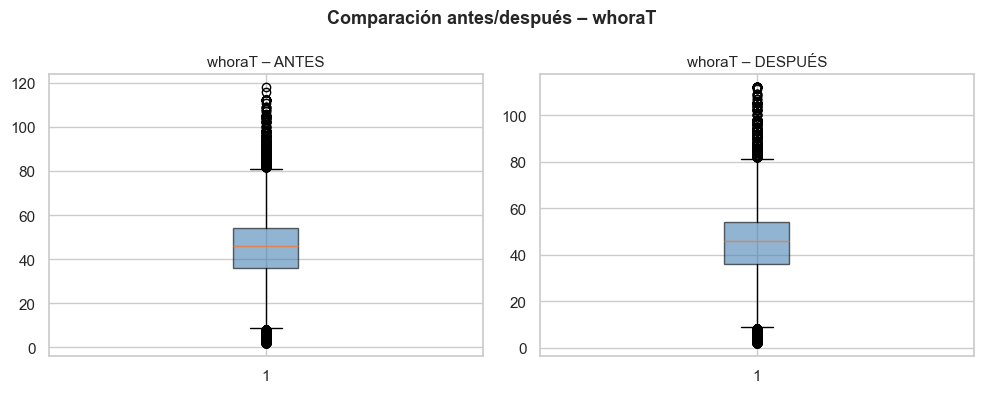

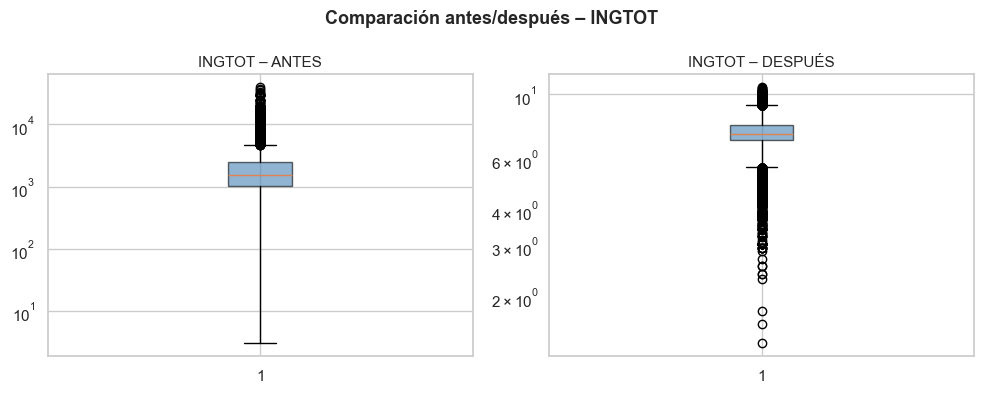

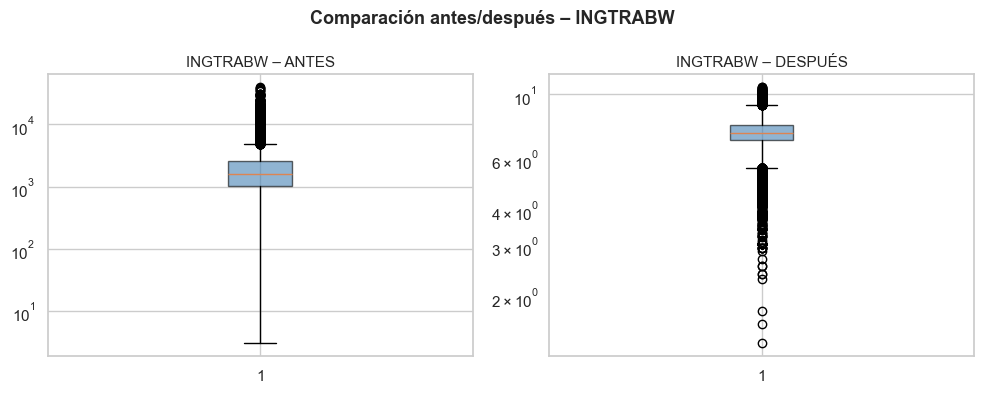

In [16]:
def boxplot_before_after(col_orig, col_post, label, df_before, df_after, use_log=False):
    """Boxplot lado a lado: antes (df_before[col_orig]) vs después (df_after[col_post])."""
    if col_orig not in df_before.columns:
        print(f"  '{col_orig}' no disponible para comparación.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
    data_b = pd.to_numeric(df_before[col_orig], errors="coerce").dropna()
    col_d  = col_post if col_post in df_after.columns else col_orig
    data_a = pd.to_numeric(df_after[col_d], errors="coerce").dropna()

    for ax, data, titulo in zip(axes, [data_b, data_a], [f"{label} – ANTES", f"{label} – DESPUÉS"]):
        ax.boxplot(data, vert=True, patch_artist=True,
                   boxprops=dict(facecolor="steelblue", alpha=0.6))
        if use_log and data.min() > 0:
            ax.set_yscale("log")
        ax.set_title(titulo, fontsize=11)

    plt.suptitle(f"Comparación antes/después – {label}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

# whoraT — antes / después (escala original)
boxplot_before_after("whoraT", "whoraT", "whoraT", df, df_outliers)

# INGTOT — antes / después (escala log)
boxplot_before_after("INGTOT", "INGTOT_log", "INGTOT", df, df_outliers, use_log=True)

# ingtrabw — columna real en el CSV (puede llamarse ingtrabw en minúsculas)
ingtrabw_orig = "INGTRABW" if "INGTRABW" in df.columns else ("ingtrabw" if "ingtrabw" in df.columns else None)
if ingtrabw_orig:
    boxplot_before_after(ingtrabw_orig, "INGTRABW_log", "INGTRABW", df, df_outliers, use_log=True)
else:
    print("  Columna 'ingtrabw' / 'INGTRABW' no encontrada.")

## 12. Validación final

In [17]:
print("=" * 55)
print("VALIDACIÓN FINAL")
print("=" * 55)

# --- Dimensiones ---
print(f"\nDimensiones finales del dataset tratado: {df_outliers.shape[0]:,} filas × {df_outliers.shape[1]} columnas")
print(f"Columnas añadidas respecto al original : {df_outliers.shape[1] - df.shape[1]}")

# --- Nulos generados por el tratamiento ---
nulos_antes  = df[numeric_cols].isna().sum().sum()
nulos_despues = df_outliers[numeric_cols].isna().sum().sum()
nuevos_nulos  = nulos_despues - nulos_antes
print(f"\nNulos en variables numéricas antes  : {nulos_antes:,}")
print(f"Nulos en variables numéricas después: {nulos_despues:,}")
print(f"  → Nulos nuevos generados por tratamiento: {nuevos_nulos:,}")

# --- Columnas con nulos restantes ---
cols_con_nulos = df_outliers[numeric_cols].isna().sum()
cols_con_nulos = cols_con_nulos[cols_con_nulos > 0].sort_values(ascending=False)
if not cols_con_nulos.empty:
    print("\nColumnas con nulos restantes (variables tratadas):")
    for col, n in cols_con_nulos.items():
        print(f"  {col:15s}: {n:,} nulos ({n / len(df_outliers) * 100:.2f}%)")
else:
    print("\nSin nulos en las variables numéricas tratadas.")

# --- Distribución del target ---
print(f"\n--- Distribución final de target_subempleo_horas ---")
display(df_outliers["target_subempleo_horas"].value_counts(dropna=False).rename("cantidad"))

# --- Integridad del target ---
assert "target_subempleo_horas" in df_outliers.columns, " target_subempleo_horas no existe"
assert df_outliers["target_subempleo_horas"].isna().sum() == 0, " target_subempleo_horas tiene nulos"
assert (df_outliers["target_subempleo_horas"].values == df["target_subempleo_horas"].values).all(), \
    " target_subempleo_horas fue modificado"
print("\n✔ target_subempleo_horas: intacto, sin nulos, sin modificaciones.")

# --- Variables de leakage no usadas ---
leakage_en_tratadas = [v for v in LEAKAGE_VARS if v in (age_cols + hours_cols + income_cols)]
assert not leakage_en_tratadas, f" Variables de leakage usadas en tratamiento: {leakage_en_tratadas}"
print("✔ Variables de leakage no utilizadas en el tratamiento de outliers.")

print("\n Validación final completada sin errores.")

VALIDACIÓN FINAL

Dimensiones finales del dataset tratado: 24,054 filas × 149 columnas
Columnas añadidas respecto al original : 11

Nulos en variables numéricas antes  : 115,393
Nulos en variables numéricas después: 115,393
  → Nulos nuevos generados por tratamiento: 0

Columnas con nulos restantes (variables tratadas):
  I345_1         : 23,491 nulos (97.66%)
  I348           : 22,516 nulos (93.61%)
  C328_T         : 21,604 nulos (89.81%)
  C331           : 20,614 nulos (85.70%)
  I342           : 15,643 nulos (65.03%)
  I339_1         : 9,203 nulos (38.26%)
  ingtrabw       : 774 nulos (3.22%)
  INGTOT         : 774 nulos (3.22%)
  INGTOTP        : 774 nulos (3.22%)

--- Distribución final de target_subempleo_horas ---


target_subempleo_horas
0    18064
1     5990
Name: cantidad, dtype: int64


✔ target_subempleo_horas: intacto, sin nulos, sin modificaciones.
✔ Variables de leakage no utilizadas en el tratamiento de outliers.

 Validación final completada sin errores.


## 13. Guardar resultados

In [18]:
out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

# 1. Dataset tratado
path_out = out_dir / "epen_outliers_handled.csv"
df_outliers.to_csv(path_out, index=False)
print(f"✔ Dataset tratado guardado en: {path_out}")
print(f"   {df_outliers.shape[0]:,} filas × {df_outliers.shape[1]} columnas")

# 2. Resumen de outliers IQR
path_iqr = out_dir / "outliers_summary.csv"
iqr_summary.reset_index().to_csv(path_iqr, index=False)
print(f"\n✔ Resumen IQR guardado en    : {path_iqr}")

# 3. Resumen comparativo antes/después
path_ba = out_dir / "outliers_before_after_summary.csv"
before_after_summary.reset_index().to_csv(path_ba, index=False)
print(f"✔ Comparación antes/después  : {path_ba}")

print("\nTodos los archivos guardados correctamente.")

✔ Dataset tratado guardado en: ..\data\processed\epen_outliers_handled.csv
   24,054 filas × 149 columnas

✔ Resumen IQR guardado en    : ..\data\processed\outliers_summary.csv
✔ Comparación antes/después  : ..\data\processed\outliers_before_after_summary.csv

Todos los archivos guardados correctamente.


## 14. Conclusiones

A partir del análisis y tratamiento de outliers realizado en este notebook, se pueden extraer las siguientes conclusiones:

1. **Identificación estadística (IQR):** Se cuantificaron los outliers estadísticos en todas las variables numéricas relevantes utilizando el método del rango intercuartílico. Las variables de ingresos presentaron los mayores porcentajes de valores atípicos por su alta asimetría.

2. **Revisión de valores conceptualmente inválidos:** Se detectaron y trataron valores imposibles en edad, horas e ingresos. Los valores fuera del rango etario válido [14–98] y los ingresos negativos fueron convertidos a `NaN`.

3. **Sin eliminación automática de observaciones:** No se eliminó ninguna fila del dataset por la sola presencia de un outlier estadístico. Cada decisión de tratamiento fue justificada por el dominio del problema.

4. **Winsorización de horas:** Las horas trabajadas superiores a 112 h/semana (16 h × 7 días) fueron acotadas mediante `clip(upper=112)` para reducir el impacto de valores de registro implausibles.

5. **Transformación logarítmica de ingresos:** Se crearon variables `_log` con `np.log1p` para todas las variables de ingresos, reduciendo la asimetría severa sin perder información de las colas altas.

6. **Flags de outliers:** Se crearon variables binarias (`C208_outlier_flag`, `whoraT_outlier_flag`, `INGTOT_outlier_flag`, `INGTRABW_outlier_flag`) antes de aplicar las modificaciones, preservando la información sobre qué registros fueron afectados.

7. **Dataset listo para la siguiente etapa:** El dataset `epen_outliers_handled.csv` conserva todas las observaciones originales, incluye las variables tratadas y las nuevas variables logarítmicas, y está listo para la etapa de train/test split y balanceo de clases.

---
> **Siguiente paso:** `03_preprocessing/reescaling_standarization_normalizing.ipynb`